In [2]:
from omegaconf import OmegaConf

from DEPRECATED.grocery_retailer_loader_historic import GroceryRetailerLoader
from ware_ops_algos.utils.visualization import plot_gantt

from scenarios.scenario_ijpe.generator.private.orders_to_canonical import to_canonical

In [3]:
# # df = pd.read_excel("./orders.xlsx", sheet_name="Clean OP Data")
# df = pd.read_excel("./OrdPick_REWE051_2026_04_13.xlsx", sheet_name="Auswahl für Framework Test")
#
# df["ARTIKELNR"] = df["ARTIKELNR"].astype(str).str[:-4]
# df["date"] = pd.to_datetime(df["NEU_DATUM"], format="%d.%m.%Y").dt.date
# if not "picklocation" in df.columns:
#     df['picklocation'] = df['House'] * 100 + df['Lagerplatz House']
# df["loc"] = df["Gang"].astype(str) + "_" + df["House"].astype(str) + "_" + df["picklocation"].astype(str)
# df["t_sec"] = pd.to_timedelta(df["BEGINN_ZEIT"].astype(str)).dt.total_seconds()

In [ ]:
df_picks, df_master = to_canonical(picks_path="instance_generator_grocery/OrdPick_REWE051_2026_04_13.xlsx", master_path="instance_generator_grocery/LBH_REWE051_2026_04_13.xlsx")

In [ ]:
df_picks

In [ ]:
cfg = OmegaConf.create({
    "data_card": {"problem_type": "OBRP", "date": "2026-04-11", "source": {"order_source": "historic"}}
})
# df_picks = load_picks("./OrdPick_REWE051_2026_04_13.xlsx")
# df_master = load_master("./LBH_REWE051_2026_04_13.xlsx")

loader = GroceryRetailerLoader("../data", None, cfg)
domain = loader.load(picks_df=df_picks, orders_path="instance_generator_grocery/OrdPick_REWE051_2026_KW16.xlsx", layout_path="../../scenarios/scenario_ijpe/data/layout.csv", bundle_dir=None)

In [ ]:
len(domain.orders.orders)

In [20]:
orders_df, layout_raw = loader._parse("../instance_generator_grocery/OrdPick_REWE051_2026_KW16.xlsx", "../data/layout.csv")

target 2026-04-11
orders         NEU_DATUM      LFDNR  AUFTRAGSNR  AUFTRAGSPOS    ARTIKELNR  \
134    2026-04-11  363723234  2604110116            4  85590760006   
148    2026-04-11  363723236  2604110116            5   3619360006   
153    2026-04-11  363723238  2604110116            6   4841190006   
158    2026-04-11  363723240  2604110116            7  23115380006   
166    2026-04-11  363723243  2604110116            8  86515990006   
...           ...        ...         ...          ...          ...   
53637  2026-04-11  363807486  2604111395           19  94843160006   
53640  2026-04-11  363804994  2604111350           45    169590024   
53641  2026-04-11  363804997  2604111350           46   7948800006   
53644  2026-04-11  363804999  2604111350           47  65408480006   
53645  2026-04-11  363805000  2604111350           48  27100210009   

                    ARTBEZ1       Q_PLATZ BEGINN_ZEIT ENDE_ZEIT  PERS_NR  ...  \
134           Evian Premium  510707050401    05:54:18

In [21]:
historic_jobs = loader.build_jobs_replay(orders_df)

<Axes: title={'center': 'Historic Pick Tours by Picker'}, xlabel='time', ylabel='picker'>

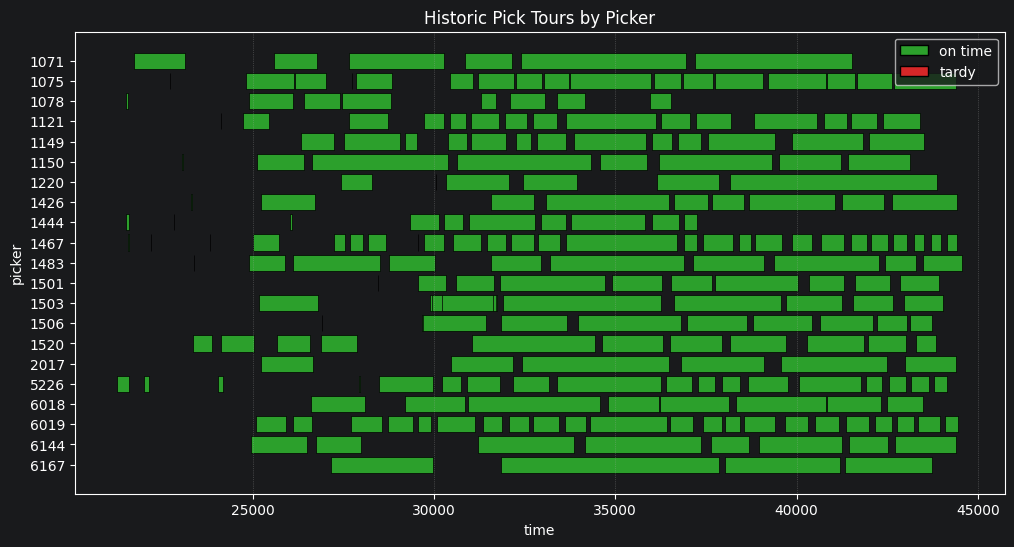

In [22]:
plot_gantt(historic_jobs, title=f"Historic Pick Tours by Picker")

In [ ]:
makespan_s = historic_jobs[-1].end_time - historic_jobs[0].start_time
makespan_h = makespan_s / 3600
print(f"Makespan: {makespan_s:.2f} seconds ({makespan_h:.2f} hours)")

In [ ]:
orders_df.columns

In [ ]:
orders_df

In [ ]:
orders_df['date'].dtype

In [ ]:
summary = orders_df[orders_df['NEU_DATUM']=="2026-04-14"].groupby(by=['hour']).agg({"KUNDENNR": "nunique", "AUFTRAGSNR": "nunique", "AUFTRAGSPOS": "count"})

In [ ]:
summary["TEs"] = summary["AUFTRAGSNR"] * 1.6

In [ ]:
summary.loc["sum"] = summary.sum(numeric_only=True)

In [ ]:
summary

In [ ]:
from ware_ops_algos.algorithms import GreedyItemAssignment, OrderNrFifoBatching, PickListRouting, EDDScheduling

layout_network = domain.layout.layout_network

item_assigner = GreedyItemAssignment(domain.storage)
# ia_sol = item_assigner.solve([historic_jobs[0].job.batch.orders[0]])

ia_sol = item_assigner.solve(domain.orders.orders)

batcher = OrderNrFifoBatching(pick_cart=domain.resources.resources[0].pick_cart, articles=domain.articles)
batching_sol = batcher.solve(ia_sol.resolved_orders)

return_router = PickListRouting(
            start_node=layout_network.start_node,
            end_node=layout_network.end_node,
            closest_node_to_start=layout_network.closest_node_to_start,
            min_aisle_position=layout_network.min_aisle_position,
            max_aisle_position=layout_network.max_aisle_position,
            distance_matrix=layout_network.distance_matrix,
            predecessor_matrix=layout_network.predecessor_matrix,
            picker=domain.resources.resources,
            gen_tour=True,
            gen_item_sequence=True,
            node_list=layout_network.node_list,
            node_to_idx={node: idx for idx, node in enumerate(list(layout_network.graph.nodes))},
            idx_to_node={idx: node for idx, node in enumerate(list(layout_network.graph.nodes))},
        )

routing_sols = []
for b in batching_sol.batches:
    routing_sol = return_router.solve(b.pick_positions)
    routing_sol.route.batch = b
    routing_sols.append(routing_sol)

In [ ]:
for r_sol in routing_sols:
    if "2604130649" in r_sol.route.order_numbers:
        print(r_sol.route.distance, r_sol.route.item_sequence)

In [ ]:
orders_df[orders_df["AUFTRAGSNR"] == 2604130649]

In [ ]:
len(batching_sol.batches)

In [ ]:
len(routing_sols[0].route.item_sequence)

In [ ]:
from ware_ops_algos.algorithms import build_jobs

routes = None
# routes = routing_sol.routes
routes = [r.route for r in routing_sols]

jobs = build_jobs(routes, domain.resources)
# scheduling_input = SchedulingInput(routes=routes, orders=orders, resources=resources)
scheduler = EDDScheduling(domain.resources)
scheduling_sol = scheduler.solve(jobs)

In [ ]:
(scheduling_sol.jobs[-1].end_time - scheduling_sol.jobs[0].start_time) / 3600

In [ ]:
scheduling_sol.jobs[-1].end_time

In [ ]:
(scheduling_sol.jobs[1].end_time - scheduling_sol.jobs[1].start_time) / 60

In [ ]:
scheduling_sol.jobs[1].job.route.distance / 1000

In [ ]:
638 / 1000

In [ ]:
(scheduling_sol.jobs[1].job.route.distance / 2306) / 60

In [ ]:
(37 * 19) / 60

In [ ]:
scheduling_sol.jobs[1].job.order_numbers

In [ ]:
638000 / 2306

In [ ]:
52*19

In [ ]:
len(scheduling_sol.jobs[1].job.route.item_sequence)

In [ ]:
from ware_ops_algos.utils.visualization import plot_route_with_directions

plot_route_with_directions(domain.layout.layout_network.graph, scheduling_sol.jobs[1].job.route.route)

In [ ]:
for j in scheduling_sol.jobs:
    if j.picker_id == 0:
        print(j.start_time, j.end_time)

In [ ]:
plot_gantt(scheduling_sol.jobs, title=f"EDD Scheduled Pick Tours by Picker")

In [ ]:
from ware_ops_algos.algorithms import RouteNode, NodeType

"""Analyze a single order: pick time vs quantity, travel time vs real distance.

Pick time  = ENDE - BEGINN per line (travel is NOT in here).
Travel time = next BEGINN - this ENDE (the gap between consecutive picks).
Distance    = lm.get_distance between consecutive pick nodes (real graph).
Speed       = distance / travel_time, and the slope of travel vs distance.

Edit ORDER_ID at the bottom (or pass on the command line) to pick the order.
"""

import numpy as np
import pandas as pd
from omegaconf import OmegaConf


ORDERS_XLSX = "./OrdPick_REWE051_2026_KW16.xlsx"
LAYOUT_CSV = "../data/layout.csv"


def _sec(t) -> float:
    return pd.to_timedelta(str(t)).total_seconds()


def build_lm():
    """LayoutManager + article_id -> (x, y) pick-node map from the grocery domain."""
    cfg = OmegaConf.create({
        "data_card": {"problem_type": "OBRP", "date": "2026-04-14",
                      "source": {"order_source": "historic"}}
    })
    loader = GroceryRetailerLoader("../data", None, cfg)
    domain = loader.load(orders_path=ORDERS_XLSX, layout_path=LAYOUT_CSV, use_cache=False)
    lm = LayoutManager(domain.layout)
    art_node = {str(loc.article_id): (loc.x, loc.y) for loc in domain.storage.locations}
    return lm, art_node


def load_order(order_id: str) -> pd.DataFrame:
    df = pd.read_excel(ORDERS_XLSX, sheet_name="Tabelle1",
                       dtype={"ARTIKELNR": str})
    df["ARTIKELNR"] = df["ARTIKELNR"].str.strip().str.replace(r"\.0$", "", regex=True)
    df = df[df["AUFTRAGSNR"].astype(str) == str(order_id)].copy()
    df["beg"] = df["BEGINN_ZEIT"].apply(_sec)
    df["end"] = df["ENDE_ZEIT"].apply(_sec)
    df["qty"] = df["MENGE_IST"].astype(float)
    return df.sort_values("beg").reset_index(drop=True)


def node(lm, art_node, article_id):
    xy = art_node.get(str(article_id))
    if xy is None:
        return None
    return RouteNode(position=(xy[0], xy[1]), node_type=NodeType.PICK)


def analyze(order_id: str):
    lm, art_node = build_lm()
    df = load_order(order_id)
    if df.empty:
        print(f"Order {order_id} not found.")
        return

    df["pick"] = df["end"] - df["beg"]
    df["travel"] = df["beg"].shift(-1) - df["end"]   # gap to NEXT pick

    # distance to the next pick (real graph)
    dist = []
    for i in range(len(df)):
        if i == len(df) - 1:
            dist.append(np.nan)
            continue
        a = node(lm, art_node, df.loc[i, "ARTIKELNR"])
        b = node(lm, art_node, df.loc[i + 1, "ARTIKELNR"])
        dist.append(lm.get_distance(a, b) if (a and b) else np.nan)
    df["dist_to_next"] = dist

    print(f"=== Order {order_id}: {len(df)} lines, {int(df['qty'].sum())} units ===\n")

    # --- pick time ---
    pick = df["pick"].to_numpy()
    print("PICK TIME (end - beginn), per line")
    print(f"  mean={pick.mean():.1f}s  median={np.median(pick):.1f}s  "
          f"min={pick.min():.0f}  max={pick.max():.0f}")
    r_pq = np.corrcoef(df["qty"], pick)[0, 1]
    sl, ic = np.polyfit(df["qty"], pick, 1)
    print(f"  vs quantity: r={r_pq:.3f}   pick = {sl:.3f}*qty + {ic:.1f}")
    print("  -> per-line constant ~{:.0f}s; quantity {} a driver\n".format(
        ic, "is" if abs(r_pq) > 0.3 else "is NOT"))

    # --- travel time ---
    t = df["travel"].to_numpy()[:-1]
    d = df["dist_to_next"].to_numpy()[:-1]
    ok = np.isfinite(t) & np.isfinite(d) & (t >= 0)
    t, d = t[ok], d[ok]
    print("TRAVEL TIME (next beginn - this ende)")
    print(f"  mean={t.mean():.1f}s  median={np.median(t):.1f}s  min={t.min():.0f}  max={t.max():.0f}")

    moving = d > 0
    if moving.sum() >= 2:
        # speed = distance / time, only for real moves with positive time
        m = moving & (t > 0)
        speed = d[m] / t[m]
        sl_d, ic_d = np.polyfit(d[m], t[m], 1)
        print(f"  distance vs travel: travel = {sl_d:.4f}*dist + {ic_d:.1f}")
        print(f"  implied speed (1/slope): {1/sl_d:.0f} dist-units/s")
        print(f"  per-move speed (dist/time): mean={np.mean(speed):.0f}  median={np.median(speed):.0f} dist-units/s")
        print(f"  (sim picker_speed = 2306)")
    print()

    # --- order totals ---
    span = df["end"].iloc[-1] - df["beg"].iloc[0]
    pick_sum = pick.sum()
    travel_sum = t[t > 0].sum()
    print("ORDER TOTALS")
    print(f"  span:   {span:.0f}s ({span/60:.1f} min)")
    print(f"  pick:   {pick_sum:.0f}s ({100*pick_sum/span:.0f}%)")
    print(f"  travel: {travel_sum:.0f}s ({100*travel_sum/span:.0f}%)")

    # --- per-line table ---
    print("\nPER-LINE:")
    show = df[["BEGINN_ZEIT", "ENDE_ZEIT", "qty", "pick", "travel", "dist_to_next"]].copy()
    show.columns = ["beginn", "ende", "qty", "pick_s", "travel_s", "dist_to_next"]
    print(show.round(1).to_string(index=False))

    return df


order_id = "2604141184"
analyze(order_id)

In [ ]:
routing_sol.route.distance / domain.resources.resources[0].speed

In [ ]:
len(routing_sol.route.item_sequence) * domain.resources.resources[0].time_per_pick

In [ ]:
from casim.state.layout_manager import LayoutManager
layout = domain.layout
lm = LayoutManager(layout)

In [ ]:
for job in historic_jobs:
    print(job.job.processing_time)

In [ ]:
ax = plot_gantt(historic_jobs, title=f"{str("test")} - Historic Pick Tours by Picker")
# ax.figure.savefig(f"./plots/historic/{str(date)}_historic.png", bbox_inches="tight")

In [ ]:
date = df_picks.date.unique()[0]
date_str = date.isoformat()  # "2024-08-30"
# date_str = "13042026"
cfg = OmegaConf.create({
    "data_card": {"problem_type": "OBRP", "date": date_str, "source": {"order_source": "historic"}}
})
# df_picks = load_picks("./OrdPick_REWE051_2026_04_13.xlsx")
# df_master = load_master("./LBH_REWE051_2026_04_13.xlsx")

loader = GroceryRetailerLoader("../data", None, cfg)
domain = loader.load(picks_df=df_picks, orders_path=df_master, layout_path="../../scenarios/scenario_ijpe/data/layout.csv", bundle_dir=None)
historic_jobs = loader._build_jobs_replay(df_picks)
# historic_jobs = loader.jobs
ax = plot_gantt(historic_jobs, title=f"{str(date)} - Historic Pick Tours by Picker")
ax.figure.savefig(f"./plots/historic/{str(date)}_historic.png", bbox_inches="tight")

In [ ]:
historic_jobs

In [ ]:
df_orders = pd.read_csv("../data/orders.csv", sep=";")

In [ ]:
df_orders

In [ ]:
df.date.unique()

In [ ]:
df.groupby(by=["date"]).agg({"AUFTRAGSNR": "nunique", "AUFTRAGSPOS": "count"})

In [ ]:
df

In [ ]:
print(df.date.dtype)
print(df.date.unique()[:3])
print(type(df.date.unique()[0]))

In [ ]:
for date in df.date.unique():
    if pd.isna(date):
        continue
    date_str = date.isoformat()  # "2024-08-30"
    cfg = OmegaConf.create({
        "data_card": {"problem_type": "OBRP", "date": date_str}
    })

    loader = GroceryRetailerLoader("../data", None, cfg)
    domain = loader.load("../data/orders.csv", "../data/layout.csv", False)
    historic_jobs = loader.jobs
    ax = plot_gantt(historic_jobs, title=f"{str(date)} - Historic Pick Tours by Picker")
    ax.figure.savefig(f"./plots/historic/{str(date)}_historic.png", bbox_inches="tight")

